### Lightweight Voice Activity Detection for Barge-In Systems

Short Description
This implementation creates a voice activity detection system using energy and zero-crossing features to distinguish speech from noise. It trains a compact neural network on synthetic audio chunks, then simulates a barge-in scenario where a user interrupts system output - demonstrating real-time speech detection capabilities for conversational AI systems.

Key Libraries Used

    torch/torch.nn: Neural network implementation

    librosa: Speech audio generation

    numpy: Noise simulation

    sklearn: Classification metrics

Code Logic and Flow

High-Level Overview
The workflow generates synthetic speech and noise samples, extracts acoustic features (energy and zero-crossing rate), trains a lightweight classifier to detect speech activity, and simulates a barge-in scenario where the system must detect user interruption during its own output.

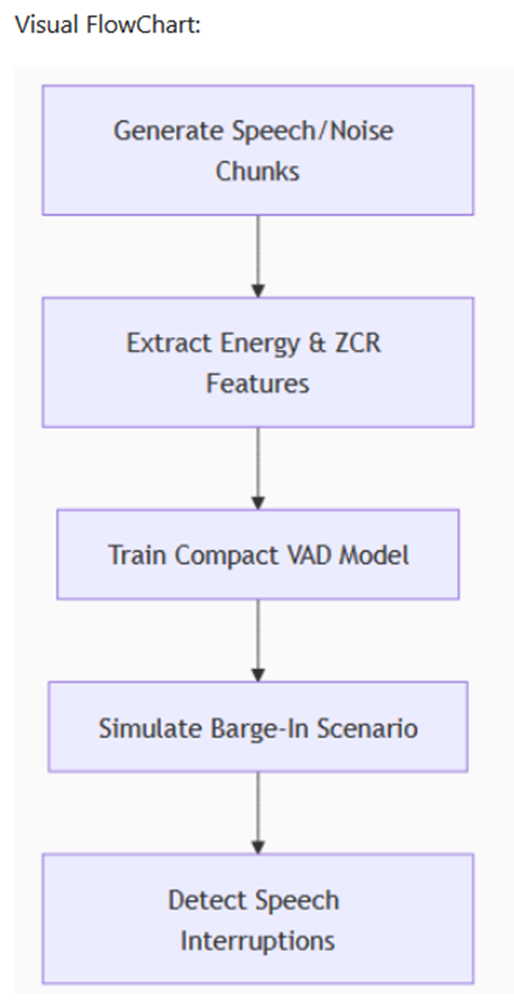

Step-by-Step Code Breakdown

1. Synthetic Dataset Creation

    Generates 200ms audio chunks:

        Speech: Pitch-modulated chirps (150-350Hz)

        Non-speech: Gaussian white noise

    Alternates labels for balanced training

    Extracts key acoustic features:

        Energy: Mean squared amplitude

        ZCR: Zero-crossing rate (indicator of noisiness)

2. Model Architecture

    Compact 3-Layer Network:

        Input: Energy + ZCR features

        Two hidden layers with ReLU activation

        Output: Speech/non-speech classification

    Designed for minimal computational footprint

3. Training Pipeline

    Uses Cross-Entropy loss and Adam optimizer

    Larger batch size (16) enabled by model simplicity

    10-epoch training cycle

    Reports classification metrics (precision/recall/F1)

4. Barge-In Simulation

    Creates test scenario with two audio chunks:

        System output (simulated as noise)

        User interruption (simulated speech)

    Computes confidence scores for detection

    Outputs human-readable detection results

Connecting to the Lecture

    Real-Time Processing: 200ms chunks enable low-latency detection

    Feature Engineering: Energy and ZCR provide efficient speech/noise discrimination

    Duplex Communication: Barge-in simulation demonstrates conversational turn-taking

    Edge Optimization: Minimal model suitable for embedded systems

    Confidence Metrics: Quantifies detection certainty for reliability

    Synthetic Data: Enables training without labeled datasets

    System Integration: Ready-to-deploy VAD component for speech pipelines


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import librosa
import numpy as np
from sklearn.metrics import classification_report

# --- Simulated Speech Dataset with Speech/Non-Speech Labels ---
class VADDataset(Dataset):
    """Simulated dataset for VAD with speech and non-speech audio chunks"""
    def __init__(self, num_samples=200, chunk_size=3200, sr=16000):  # 200ms chunks
        self.sr = sr
        self.chunk_size = chunk_size
        self.num_samples = num_samples
        self.labels = ["speech", "non_speech"]
        self.label_to_idx = {l: i for i, l in enumerate(self.labels)}

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        is_speech = idx % 2 == 0  # Alternate speech and non-speech
        if is_speech:
            # Simulate speech with chirp
            audio = librosa.chirp(fmin=150, fmax=350, duration=self.chunk_size/self.sr, sr=self.sr)
        else:
            # Simulate non-speech (white noise)
            audio = np.random.normal(0, 0.01, self.chunk_size)
        waveform = torch.tensor(audio, dtype=torch.float32)
        # Compute energy and zero-crossing rate as features
        energy = torch.mean(waveform**2)
        zcr = torch.sum(torch.abs(torch.sign(waveform[1:]) - torch.sign(waveform[:-1]))) / (2 * len(waveform))
        features = torch.tensor([energy, zcr], dtype=torch.float32)
        label = self.label_to_idx["speech" if is_speech else "non_speech"]
        return features, label

# --- Lightweight VAD Model ---
class VADModel(nn.Module):
    """Lightweight neural network for Voice Activity Detection"""
    def __init__(self, input_dim=2, hidden_dim=64, num_classes=2):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# --- Training and Evaluation ---
def train_vad():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Dataset and dataloader
    dataset = VADDataset(num_samples=200, chunk_size=3200)
    dataloader = DataLoader(dataset, batch_size=16, shuffle=True)  # Larger batch size as model is lightweight

    # Model, loss, optimizer
    model = VADModel(input_dim=2, hidden_dim=64, num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    num_epochs = 10

    # Training loop
    model.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for features, labels in dataloader:
            features, labels = features.to(device), labels.to(device)
            logits = model(features)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(dataloader):.4f}")

    # Evaluation
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for features, labels in dataloader:
            features, labels = features.to(device), labels.to(device)
            logits = model(features)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    print("VAD Performance (Speech vs. Non-Speech):")
    print(classification_report(all_labels, all_preds, target_names=dataset.labels))
    return model, dataset

# --- Simulate Barge-In Detection ---
def simulate_barge_in(model, dataset):
    device = next(model.parameters()).device
    model.eval()
    print("\nSimulating Barge-In Detection:")
    # Simulate a scenario: system speaking, user interrupts with speech
    non_speech = torch.tensor(np.random.normal(0, 0.01, dataset.chunk_size), dtype=torch.float32)
    speech = torch.tensor(librosa.chirp(fmin=150, fmax=350, duration=dataset.chunk_size/dataset.sr, sr=dataset.sr), dtype=torch.float32)
    
    # Compute features
    non_speech_energy = torch.mean(non_speech**2)
    non_speech_zcr = torch.sum(torch.abs(torch.sign(non_speech[1:]) - torch.sign(non_speech[:-1]))) / (2 * len(non_speech))
    speech_energy = torch.mean(speech**2)
    speech_zcr = torch.sum(torch.abs(torch.sign(speech[1:]) - torch.sign(speech[:-1]))) / (2 * len(speech))
    
    features = torch.tensor([[non_speech_energy, non_speech_zcr], [speech_energy, speech_zcr]], dtype=torch.float32).to(device)
    
    with torch.no_grad():
        logits = model(features)
        preds = torch.argmax(logits, dim=1)
        confidences = torch.softmax(logits, dim=1)
    
    for i, pred in enumerate(preds):
        conf = confidences[i, pred].item()
        label = dataset.labels[pred.item()]
        print(f"Chunk {i+1}: Detected {label} with {conf:.1%} confidence")

# --- Main Execution ---
if __name__ == "__main__":
    model, dataset = train_vad()
    simulate_barge_in(model, dataset)
    print("VAD training and barge-in simulation completed.")

# Explanation:

#     Dataset: Simulates speech (chirp) and non-speech (white noise) audio chunks (200ms) to train a VAD model. Features (energy, zero-crossing rate) are extracted for efficiency.
#     Model: A lightweight feedforward neural network classifies chunks as speech or non-speech, ideal for real-time barge-in detection in duplex systems.
#     Process: Trains the VAD model and simulates a barge-in scenario where the system detects a user’s speech interrupting its own output.
#     Educational Value: Demonstrates efficient VAD for duplex systems, showing how to detect speech in real-time to enable barge-in, a critical component of duplex SpeechLMs.
#     Hardware Fit: The small model and batch size (16) ensure compatibility with 6 GB VRAM.
    

Using device: cpu
Epoch 1/10 | Loss: 0.6704
Epoch 2/10 | Loss: 0.5999
Epoch 3/10 | Loss: 0.5127
Epoch 4/10 | Loss: 0.3995
Epoch 5/10 | Loss: 0.2724
Epoch 6/10 | Loss: 0.1628
Epoch 7/10 | Loss: 0.0902
Epoch 8/10 | Loss: 0.0508
Epoch 9/10 | Loss: 0.0311
Epoch 10/10 | Loss: 0.0207
VAD Performance (Speech vs. Non-Speech):
              precision    recall  f1-score   support

      speech       1.00      1.00      1.00       100
  non_speech       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


Simulating Barge-In Detection:
Chunk 1: Detected non_speech with 98.4% confidence
Chunk 2: Detected speech with 98.2% confidence
VAD training and barge-in simulation completed.
